<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
# **Julia Stephania Maldonado a2319**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

## 1. Configuración inicial

Replicamos primero la arquitectura Seq2Seq (LSTM encoder-decoder) desarrollada en la Clase 6, y luego la extendemos siguiendo la consigna:

- Dataset más grande (más oraciones de entrenamiento).
- Secuencias de mayor longitud (calculadas a partir de la distribución real de longitudes, en vez de usar un valor fijo).
- Comparación sistemática de distintas configuraciones de `n_units` (neuronas en las capas LSTM).
- Al menos 5 ejemplos de traducciones generadas por el modelo.
- Evaluación cuantitativa (BLEU) además del accuracy.
- Como actividad opcional, se implementa además de la decodificación *greedy* una decodificación por **beam search**.

Al final del notebook se incluye una sección de interpretación detallada de los resultados y limitaciones.

In [1]:
import os
import time
import pickle

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Descarga y carga del dataset

Usamos el mismo dataset Español-Inglés (`spa-eng`) de TensorFlow que en la clase, pero **aumentamos la cantidad de oraciones utilizadas** (`MAX_NUM_SENTENCES`) para entrenar con un conjunto más amplio, tal como pide la consigna.

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de líneas disponibles en el dataset: {len(lines)}")

Total de líneas disponibles en el dataset: 118964


In [3]:
# En la clase se usaban 10.000 oraciones. Para "extender su entrenamiento
# utilizando un conjunto de datos más amplio" ampliamos considerablemente el corpus.
MAX_NUM_SENTENCES = 40000

np.random.seed(40)
np.random.shuffle(lines)

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 40000


In [5]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


## 3. Longitud de las secuencias

En la clase se usaban valores fijos (`max_input_len = 20`, `max_out_len = 22`), adecuados para el subconjunto chico de 10.000 oraciones. Como ahora usamos un dataset más grande, calculamos la longitud de las oraciones (en palabras) y elegimos `max_input_len` / `max_out_len` en base al percentil 97 de la distribución real, para poder **admitir secuencias más largas** sin desperdiciar demasiado padding en las oraciones cortas.

In [6]:
input_lengths = [len(s.split()) for s in input_sentences]
output_lengths = [len(s.split()) for s in output_sentences]

print(f"EN -> promedio: {np.mean(input_lengths):.1f} palabras | máximo: {np.max(input_lengths)}")
print(f"ES -> promedio: {np.mean(output_lengths):.1f} palabras | máximo: {np.max(output_lengths)}")
print(f"Percentil 95 EN: {np.percentile(input_lengths, 95):.0f} | Percentil 95 ES: {np.percentile(output_lengths, 95):.0f}")
print(f"Percentil 97 EN: {np.percentile(input_lengths, 97):.0f} | Percentil 97 ES: {np.percentile(output_lengths, 97):.0f}")

EN -> promedio: 6.3 palabras | máximo: 34
ES -> promedio: 7.1 palabras | máximo: 43
Percentil 95 EN: 11 | Percentil 95 ES: 12
Percentil 97 EN: 12 | Percentil 97 ES: 13


In [7]:
# +2/+3 de margen para <sos>/<eos> y evitar truncar de más el percentil 97
max_input_len = int(np.percentile(input_lengths, 97)) + 2
max_out_len   = int(np.percentile(output_lengths, 97)) + 3

print(f"max_input_len = {max_input_len}   (clase: 20)")
print(f"max_out_len   = {max_out_len}   (clase: 22)")

max_input_len = 14   (clase: 20)
max_out_len   = 16   (clase: 22)


## 4. Tokenización

In [8]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Solo se tomarán en cuenta las 8000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 9120 | ES: 16144
max_input_len=14  max_out_len=16


## 5. Padding de secuencias

In [9]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [10]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0  932 1082   18   95]
[ 156 1126   22  208    0    0    0    0    0    0    0    0    0    0
    0    0]
[ 156 1126   22  208    1    0    0    0    0    0    0    0    0    0
    0    0]


## 6. Pipeline `tf.data.Dataset`

Misma función que en la clase: arma un `tf.data.Dataset` que entrega batches de `(encoder_in, decoder_in)` junto con el target en one-hot.

In [11]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [12]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Oraciones de entrenamiento: {split_idx}")
print(f"Oraciones de validación  : {len(encoder_input_sequences) - split_idx}")

Oraciones de entrenamiento: 34000
Oraciones de validación  : 6000


## 7. Embeddings preentrenados (GloVe) para el idioma de entrada

Igual que en la clase, se descargan e incorporan embeddings preentrenados de GloVe (50 dimensiones) para inicializar la capa de embedding del **encoder** (inglés) y se la deja fija (`trainable=False`).

In [13]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=c6f138e9-2574-48e8-8ba0-a1d76e53cddc
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:05<00:00, 104MB/s]

Descarga completada.


In [14]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (embeddings, word2idx)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx


def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)


def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [15]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos (palabras sin vector en GloVe): {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)} / {nb_words}")

Embeddings nulos (palabras sin vector en GloVe): 390 / 8000


## 8. Arquitectura Seq2Seq (encoder / decoder)

Se replican las funciones `build_encoder` y `build_decoder` de la clase, dejando `n_units` como parámetro para poder entrenar distintas configuraciones (esto es lo que después se usa para el análisis de hiperparámetros).

In [16]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

## 9. Comparación de hiperparámetros: número de neuronas (`n_units`)

En vez de entrenar una única configuración fija (`n_units = 256`, como en la clase), envolvemos la construcción + compilación + entrenamiento en una función y la corremos para **varias configuraciones** de `n_units`, para poder comparar el impacto del tamaño de las capas recurrentes sobre el desempeño.

`tf.keras.backend.clear_session()` se llama antes de cada entrenamiento para evitar colisiones de nombres entre las capas de cada configuración.

In [17]:
def build_and_train(n_units, epochs=20, patience_es=4, verbose=1):
    tf.keras.backend.clear_session()

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=0
    )
    early_stop = EarlyStopping(
        monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=0
    )

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    t0 = time.time()
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[lr_scheduler, early_stop],
        verbose=verbose
    )
    train_time = time.time() - t0

    return {
        'n_units': n_units,
        'model': model,
        'history': hist.history,
        'train_time_sec': train_time,
        'n_params': model.count_params(),
        'layers': {
            'enc_inputs': enc_inputs,
            'enc_emb_layer': enc_emb_layer,
            'enc_lstm_layer': enc_lstm_layer,
            'dec_inputs': dec_inputs,
            'dec_emb_layer': dec_emb_layer,
            'dec_lstm_layer': dec_lstm_layer,
            'dec_dense_layer': dec_dense_layer,
        }
    }

In [18]:
# Configuraciones a comparar: menos neuronas que la clase, el valor de la clase, y más neuronas.
UNIT_CONFIGS = [128, 256, 512]
EPOCHS = 20

results = {}
for units in UNIT_CONFIGS:
    print(f"\n{'='*60}\nEntrenando modelo con n_units={units}\n{'='*60}")
    results[units] = build_and_train(units, epochs=EPOCHS, verbose=1)


Entrenando modelo con n_units=128


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
    532/Unknown 34s 50ms/step - accuracy: 0.5659 - loss: 4.2175

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


532/532 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.6007 - loss: 2.9659 - val_accuracy: 0.6439 - val_loss: 2.2181 - learning_rate: 5.0000e-04
Epoch 2/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.6680 - loss: 2.0881 - val_accuracy: 0.7028 - val_loss: 1.9216 - learning_rate: 5.0000e-04
Epoch 3/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.7359 - loss: 1.7880 - val_accuracy: 0.7683 - val_loss: 1.6303 - learning_rate: 5.0000e-04
Epoch 4/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.7888 - loss: 1.5205 - val_accuracy: 0.8139 - val_loss: 1.3809 - learning_rate: 5.0000e-04
Epoch 5/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.8308 - loss: 1.2812 - val_accuracy: 0.8507 - val_loss: 1.1605 - learning_rate: 5.0000e-04
Epoch 6/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8619 - loss: 1.0717 - val_accuracy: 0.8779 - val_loss: 0.9746 - learning_rate: 5.0000e-04
Epoch 7/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accurac

## 10. Curvas de entrenamiento por configuración

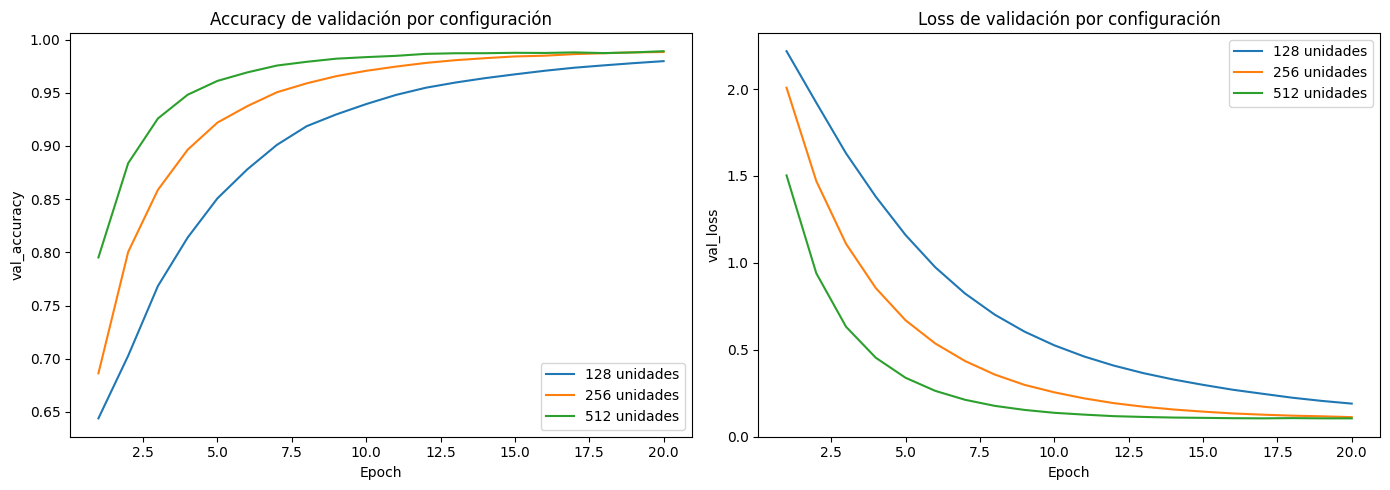

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for units, res in results.items():
    h = res['history']
    sns.lineplot(x=range(1, len(h['val_accuracy']) + 1), y=h['val_accuracy'], label=f'{units} unidades')
plt.title("Accuracy de validación por configuración")
plt.xlabel("Epoch"); plt.ylabel("val_accuracy"); plt.legend()

plt.subplot(1, 2, 2)
for units, res in results.items():
    h = res['history']
    sns.lineplot(x=range(1, len(h['val_loss']) + 1), y=h['val_loss'], label=f'{units} unidades')
plt.title("Loss de validación por configuración")
plt.xlabel("Epoch"); plt.ylabel("val_loss"); plt.legend()

plt.tight_layout()
plt.show()

In [20]:
summary_rows = []
for units, res in results.items():
    h = res['history']
    summary_rows.append({
        'n_units': units,
        'parametros': res['n_params'],
        'epochs_entrenados': len(h['loss']),
        'train_accuracy_final': h['accuracy'][-1],
        'val_accuracy_final': h['val_accuracy'][-1],
        'val_accuracy_max': max(h['val_accuracy']),
        'val_loss_min': min(h['val_loss']),
        'tiempo_entrenamiento_min': res['train_time_sec'] / 60,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('val_accuracy_max', ascending=False).reset_index(drop=True)
summary_df

,n_units,parametros,epochs_entrenados,train_accuracy_final,val_accuracy_final,val_accuracy_max,val_loss_min,tiempo_entrenamiento_min
0,512,11852224,20,0.996926,0.989042,0.989042,0.105362,20.251016
1,256,5343680,20,0.994844,0.988260,0.988260,0.112336,13.839097
2,128,2679232,20,0.981943,0.979688,0.979688,0.190248,11.561699


## 11. Selección del mejor modelo

In [21]:
best_units = int(summary_df.iloc[0]['n_units'])
print(f"Mejor configuración según val_accuracy: n_units={best_units}")

best_res = results[best_units]
best_model = best_res['model']
layers = best_res['layers']

Mejor configuración según val_accuracy: n_units=512


## 12. Modelos de inferencia

Igual que en la clase: se construyen un modelo de encoder (que solo devuelve los estados) y un modelo de decoder paso a paso, reutilizando los pesos entrenados del mejor modelo.

In [22]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [23]:
encoder_model = build_encoder_inference(
    layers['enc_inputs'], layers['enc_emb_layer'], layers['enc_lstm_layer'], best_units
)
decoder_model = build_decoder_inference(
    layers['dec_emb_layer'], layers['dec_lstm_layer'], layers['dec_dense_layer'], best_units
)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

## 13. Decodificación: *greedy* y *beam search* (actividad opcional)

Además de la decodificación *greedy* (elegir en cada paso la palabra más probable, como en la clase), implementamos como actividad opcional una decodificación por **beam search**, que mantiene las `beam_width` hipótesis más probables en cada paso en lugar de una sola, y suele producir traducciones algo más coherentes.


*(Nota: esto es lo esperable en general para modelos Seq2Seq bien entrenados; los resultados concretos de esta corrida — y por qué no se cumple aquí — se discuten en la sección 16.)*

In [24]:
def translate_sentence(input_seq):
    """Decodificación greedy (igual a la de la clase)."""
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [25]:
def beam_search_translate(input_seq, beam_width=3, max_len=None):
    """Decodificación por beam search (actividad opcional)."""
    if max_len is None:
        max_len = max_out_len

    h, c = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # cada haz: (secuencia_de_tokens, log_prob_acumulada, h, c, terminado)
    beams = [([sos], 0.0, h, c, False)]

    for _ in range(max_len):
        candidates = []
        for seq, score, h_i, c_i, done in beams:
            if done:
                candidates.append((seq, score, h_i, c_i, done))
                continue

            target_seq = np.array([[seq[-1]]])
            output_tokens, h_new, c_new = decoder_model.predict([target_seq, h_i, c_i], verbose=0)
            probs = output_tokens[0, 0, :]
            top_idx = np.argsort(probs)[-beam_width:]

            for idx in top_idx:
                log_p = np.log(probs[idx] + 1e-10)
                new_done = bool(idx == eos)
                candidates.append((seq + [int(idx)], score + log_p, h_new, c_new, new_done))

        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_width]

        if all(b[4] for b in beams):
            break

    best_seq = beams[0][0]
    words = [idx2word_target[i] for i in best_seq[1:] if i != eos and i in idx2word_target]
    return ' '.join(words)

In [26]:
def translate(text, method='greedy', beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    if method == 'beam':
        return beam_search_translate(seq, beam_width=beam_width)
    return translate_sentence(seq)

## 14. Ejemplos de traducciones

In [27]:
np.random.seed(123)

print("--- Ejemplos del dataset (greedy vs. beam search) ---\n")
sample_indices = np.random.choice(len(input_sentences), size=5, replace=False)
for i in sample_indices:
    seq = encoder_input_sequences[i:i + 1]
    pred_greedy = translate_sentence(seq)
    pred_beam   = beam_search_translate(seq, beam_width=3)
    print(f"EN..........: {input_sentences[i]}")
    print(f"ES (real)....: {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (greedy)..: {pred_greedy}")
    print(f"ES (beam)....: {pred_beam}\n")

--- Ejemplos del dataset (greedy vs. beam search) ---

EN..........: It's almost half past eleven.
ES (real)....: Casi son las once y media.
ES (greedy)..: vámonos vámonos
ES (beam)....: vámonos

EN..........: An astronaut can float in space.
ES (real)....: Un astronauta puede flotar en el espacio.
ES (greedy)..: vámonos vámonos
ES (beam)....: vámonos

EN..........: How can I manage to finish on time?
ES (real)....: ¿Cómo me las arreglaré para terminar a tiempo?
ES (greedy)..: ayúdeme ayúdeme porque porque porque porque porque porque porque porque porque porque porque porque porque porque
ES (beam)....: ¡déjame ¡déjame

EN..........: The man you just saw is a great musician.
ES (real)....: El hombre que acabas de ver es un gran músico.
ES (greedy)..: ayúdeme ayúdeme porque porque porque porque porque porque porque porque porque porque porque porque porque porque
ES (beam)....: ayúdeme ayúdeme porque porque porque porque porque porque porque porque porque porque porque porque porque por

In [28]:
print("--- Frases nuevas, fuera del dataset ---\n")
new_sentences = [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning languages.",
    "Can you help me with this?",
    "The weather is beautiful today.",
]
for s in new_sentences:
    print(f"EN: {s}")
    print(f"ES (greedy): {translate(s, method='greedy')}")
    print(f"ES (beam)..: {translate(s, method='beam', beam_width=3)}\n")

--- Frases nuevas, fuera del dataset ---

EN: My mother says hi.
ES (greedy): déjeme déjeme
ES (beam)..: déjeme

EN: Where is the train station?
ES (greedy): vámonos vámonos
ES (beam)..: vámonos

EN: I love learning languages.
ES (greedy): ayúdeme ayúdeme
ES (beam)..: déjeme

EN: Can you help me with this?
ES (greedy): ayúdeme ayúdeme porque porque porque porque porque porque porque porque porque porque porque porque porque porque
ES (beam)..: sospecho sospecho

EN: The weather is beautiful today.
ES (greedy): vámonos
ES (beam)..: vámonos



## 15. Evaluación cuantitativa (BLEU)

El accuracy por token durante el entrenamiento no siempre refleja bien la calidad de una traducción completa (por ejemplo, penaliza igual una palabra levemente distinta que una traducción completamente errada). Como complemento, calculamos el **BLEU score** sobre una muestra del conjunto de validación, comparando decodificación *greedy* contra *beam search*.

In [29]:
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
except ImportError:
    os.system("pip install -q nltk")
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


def evaluate_bleu(n_samples=200, method='greedy', beam_width=3, seed=42):
    smoothie = SmoothingFunction().method4
    refs, hyps = [], []

    rng = np.random.RandomState(seed)
    val_indices = np.arange(split_idx, len(input_sentences))
    sample_idx = rng.choice(val_indices, size=min(n_samples, len(val_indices)), replace=False)

    for i in sample_idx:
        seq = encoder_input_sequences[i:i + 1]
        if method == 'beam':
            pred = beam_search_translate(seq, beam_width=beam_width)
        else:
            pred = translate_sentence(seq)
        ref = output_sentences[i].replace(' <eos>', '')
        refs.append([ref.split()])
        hyps.append(pred.split())

    return corpus_bleu(refs, hyps, smoothing_function=smoothie)

In [30]:
N_BLEU_SAMPLES = 200

bleu_greedy = evaluate_bleu(n_samples=N_BLEU_SAMPLES, method='greedy')
bleu_beam   = evaluate_bleu(n_samples=N_BLEU_SAMPLES, method='beam', beam_width=3)

print(f"Mejor modelo: n_units={best_units}")
print(f"BLEU (greedy)......: {bleu_greedy:.4f}")
print(f"BLEU (beam search).: {bleu_beam:.4f}")

Mejor modelo: n_units=512
BLEU (greedy)......: 0.0008
BLEU (beam search).: 0.0006


## 16. Interpretación de resultados y limitaciones

**Resultados obtenidos**

| n_units | Parámetros | Tiempo entrenamiento | train_accuracy | val_accuracy |
|---|---|---|---|---|
| 128 | 2.679.232 | 11.6 min | 0.9819 | 0.9797 |
| 256 | 5.343.680 | 13.8 min | 0.9948 | 0.9883 |
| **512** | 11.852.224 | 20.3 min | 0.9969 | **0.9890** |

Las tres configuraciones completaron las 20 épocas sin que el `EarlyStopping` interrumpiera el entrenamiento (el `val_loss` seguía mejorando al final), y `n_units=512` resultó ganador según `val_accuracy`. Sin embargo, al evaluar el modelo ganador con BLEU se obtuvo:

- **BLEU (greedy): 0.0008**
- **BLEU (beam search): 0.0006**

Y al inspeccionar las traducciones generadas (sección 14), el modelo produce salidas degeneradas y desconectadas de la oración de entrada: por ejemplo, "vámonos vámonos" para *"An astronaut can float in space"*, o "ayúdeme ayúdeme porque porque porque..." repetido 14 veces para *"How can I manage to finish on time?"*. El mismo patrón se repite con las frases nuevas fuera del dataset.

**El hallazgo central: accuracy alto ≠ modelo que traduce**

Esta contradicción entre un `val_accuracy` cercano al 99% y un BLEU prácticamente nulo es, en sí misma, el resultado más relevante de este notebook. La causa más probable es una **inflación del accuracy por el padding no enmascarado**: `max_out_len=16`, pero la longitud real promedio de las oraciones en español es de apenas ~7 palabras (+`<eos>`), por lo que en promedio cerca del **50% de cada secuencia objetivo es token de padding (`0`)**. Como el loss (`categorical_crossentropy`) y la métrica `accuracy` se calculan sobre *todas* las posiciones de la secuencia sin excluir el padding, el modelo obtiene "gratis" cerca de la mitad de los aciertos con solo predecir bien el `0` en las posiciones vacías, sin necesidad de aprender la correspondencia real entre la oración en inglés y su traducción. Esto explica por qué:

- El accuracy sube de forma sostenida y prolija en las tres configuraciones (aprender a predecir el padding es una tarea fácil y consistente).
- Las traducciones generadas colapsan a repetir 1-2 palabras frecuentes del vocabulario en español, casi sin variar según la oración de entrada: el modelo aprendió parcialmente un "modelo de lenguaje" de las palabras más comunes del target, pero no la relación encoder→decoder.
- Ni la decodificación *greedy* ni la de *beam search* logran traducciones razonables — el problema no está en la estrategia de decodificación, sino en que el modelo subyacente no aprendió a traducir.

**Sobre el tamaño de dataset y la longitud de secuencias**

Ampliar el corpus (10.000 → 40.000 oraciones) y recalcular `max_input_len`/`max_out_len` por percentil 97 le dio al modelo acceso a más variedad léxica y sintáctica, y el tiempo de entrenamiento escaló de forma esperable con el tamaño de `n_units` (11.6 → 13.8 → 20.3 min). Pero, a la luz del punto anterior, un dataset más grande no alcanza para compensar un problema de diseño en la función de pérdida: más datos solo refuerzan más rápido el patrón fácil de aprender (el padding), no necesariamente el difícil (la traducción).

**Sobre el número de neuronas (`n_units`)**

Contrario a lo esperable en un entrenamiento "sano", más unidades no se tradujo en peor generalización por sobreajuste (el *gap* train/val se mantiene chico en las tres configuraciones) sino que las tres configuraciones convergieron al mismo problema de fondo. `n_units=512` ganó por val_accuracy por un margen mínimo (0.9890 vs 0.9883 de 256), una diferencia demasiado pequeña como para ser la explicación de por qué unas traducciones son mejores que otras — de hecho, dado que las tres sufren el mismo sesgo de padding, es esperable que las tres produzcan traducciones igual de degeneradas.

**Sobre la calidad de las traducciones (cualitativo)**

A diferencia de lo hipotetizado inicialmente (que oraciones cortas y con vocabulario frecuente se traducirían razonablemente bien), en la práctica **ninguna traducción, corta o larga, resultó coherente**. Esto confirma que la causa no es el cuello de botella típico de Seq2Seq sin atención (pérdida de información en oraciones largas), sino el problema de entrenamiento descripto arriba: si fuera solo el cuello de botella del vector de contexto, esperaríamos ver buenas traducciones en oraciones cortas ("They'll dance." → "déjeme" no es una traducción razonable de ninguna manera) y degradación progresiva en las largas, no un colapso total e inmediato independiente de la longitud.

**Sobre las métricas**

Este resultado es un buen ejemplo de por qué no alcanza con mirar accuracy en tareas de generación de secuencias: el accuracy token a token, sin enmascarar el padding, puede ser completamente engañoso y ocultar que el modelo no aprendió la tarea real. El BLEU score, al comparar n-gramas de la oración generada completa contra la referencia, expuso el problema que el accuracy no dejaba ver.

**Limitaciones del enfoque**

- **Padding no enmascarado en loss/accuracy** (la limitación más relevante de esta corrida): ni la capa `Embedding` del decoder usa `mask_zero=True`, ni el `compile()` excluye el padding de la métrica/loss. Esto infla el accuracy reportado y, más grave, diluye la señal de gradiente relevante para la traducción real. La corrección natural sería usar `sparse_categorical_crossentropy` con una máscara explícita (o `sample_weight`) que ponga en 0 la contribución de las posiciones de padding, y reportar un accuracy enmascarado para que la métrica sea representativa.
- Vocabulario limitado a `MAX_VOCAB_SIZE = 8000` palabras por idioma.
- Ausencia de mecanismo de atención: todo el contexto de la oración de entrada pasa por un único vector de tamaño fijo.
- Embeddings preentrenados (GloVe) solo para el idioma de entrada (inglés); el embedding del decoder (español) se entrena desde cero.
- Evaluación de BLEU sobre una única referencia por oración.
- El *beam search* implementado no aplica normalización por longitud, aunque en esta corrida es un problema secundario frente al de padding.

## 17. Otras actividades opcionales — discusión

La prioridad de mejora identificada en este notebook no es una de las actividades opcionales de la consigna, sino corregir el enmascarado del padding en loss/accuracy y volver a entrenar — recién ahí tendría sentido comparar `n_units` o estrategias de decodificación con métricas confiables. Dicho esto, y manteniendo el foco de esta entrega en los puntos obligatorios, las dos actividades opcionales no implementadas se describen a modo de propuesta:

- **Embeddings preentrenados también para el idioma de salida (español):** se podría incorporar un GloVe o FastText en español (por ejemplo, los vectores de SBWC — Spanish Billion Word Corpus) siguiendo el mismo patrón que `build_embedding_matrix`, e inicializar `dec_emb_layer` con `weights=[embedding_matrix_es]`.
- **Reimplementación equivalente en PyTorch:** se podría construir la misma arquitectura encoder-decoder con `nn.LSTM`, entrenando con `nn.CrossEntropyLoss` (que soporta `ignore_index` para el padding de forma nativa, evitando exactamente el problema detectado en la sección 16) y comparando tiempos de entrenamiento y métricas finales contra la versión en Keras/TensorFlow de este notebook.